In [9]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Common period for all datasets (1981-2015)

In [10]:
iyear = 1981
fyear = 2015

# Precipitation datasets used

In [11]:
models = ['APHRO','CHIRPS','CRU','ERA5','GPCP','HARv2']

# Subregions we defined

In [12]:
domains = ['HMA','HK','SL','TP','CH','SEH']

# Precipitation (tp) datasets loading

Monthly mean are computed and converted to mm per month. For more details of this part, go to : '/home/bricej/MyPythonLibrary/StageM2_IVT/script/compute_tp_datasets_mm_month'

In [13]:
tp_datasets = {} # dictionnary to store precipitation datasets

# path of the files for the different datasets
files = {
    'APHRO': 'tp_HMA_1951-2015_APHRO.nc',
    'GPCP': 'tp_HMA_1891-2019_GPCP.nc',
    'CRU': 'tp_HMA_1901-2020_CRU.nc',
    'CHIRPS': 'tp_HMA_1981-2025_CHIRPS.nc',
    'HARv2': 'tp_HMA_1980-2023_HARv2.nc',
    'ERA5': 'tp_HMA_1940-2025_ERA5.nc'
}
path = '/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/' # path + files = precipitation datasets

# function to reduce the domain taken for HARv2 dataset because of its special coordinates
def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

# data storing in tp_datasets
for model in models: # for every dataset
    tp_datasets[model] = {}
    tp_model = xr.open_dataset(path + files[model])['tp'] # open dataset
    tp_model=tp_model.sel(time=slice(str(iyear),str(fyear))) # take only the 1981-2015 period
    
    for domain in domains: # and for every subregions
        if model == 'HARv2':
            latS,latN,lonW,lonE = coord_domain(domain)
            tp_datasets[model][domain]=xy_sel_dom(tp_model,latS,latN,lonW,lonE) # reduce the domain taken for HARv2 with the function
        else:
            tp_datasets[model][domain] = field_dom(tp_model,domain) # reduce the domain taken for the other datasets

# Monthly selection of precipitation datasets (spatial mean)

In [14]:
tp_month_dict = {} # dictionnary to store monthly selection of precipitation

for model in models:
    tp_month_dict[model]={}
    for domain in domains:
        tp_month_dict[model][domain] = tp_datasets[model][domain].groupby('time.month')
        if model == 'HARv2':
            tp_month_dict[model][domain] = tp_month_dict[model][domain].mean(dim=['south_north','west_east'], skipna=True) # spatial mean
        else:
            tp_month_dict[model][domain] = tp_month_dict[model][domain].mean(dim=['lat','lon'], skipna=True) # spatial mean

# Monthly trends for precipitation datasets

In [15]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] # months of the year

tp_trend_dict = {} # dictionnary to store all the statistics fo the linear regression

for model in models:
    tp_trend_dict[model]={}
    for domain in domains:
        tp_trend_dict[model][domain]={}
        for i, mo in enumerate(months):
            da_m = tp_month_dict[model][domain].where(tp_month_dict[model][domain].time.dt.month == i+1,drop=True) # month selection
            tp_trend_dict[model][domain][mo] = stats.linregress(da_m.time.dt.year.values,da_m.values) # linear regression

### Store the slopes

In [16]:
tp_slope_dict = {}
for model in models:
    tp_slope_dict[model] = {}
    for dom in domains:
        slopes = []
        for mon in months:
            # récupère uniquement la slope
            slope_val = tp_trend_dict[model][dom][mon].slope * 10 # slope & mm/month/year --> mm/month/decade
            slopes.append(slope_val)
        # on transforme en DataArray
        tp_slope_dict[model][dom] = xr.DataArray(slopes,coords={'month': np.arange(1, 13)},dims=['month'])

### Store the p-values of the trends

In [17]:
tp_pvalue_dict = {}
for model in models:
    tp_pvalue_dict[model] = {}
    for dom in domains:
        pvalues = []
        for mon in months:
            # récupère uniquement la p-value
            pvalue_val = tp_trend_dict[model][dom][mon].pvalue
            pvalues.append(pvalue_val)
        # on transforme en DataArray
        tp_pvalue_dict[model][dom] = xr.DataArray(pvalues,coords={'month': np.arange(1, 13)},dims=['month'])

# Converting the slopes in percentage trends

In [18]:
tp_percent_dict = {} # dictionnary to store the monthly percentage trend of the datasets
month_num=[1,2,3,4,5,6,7,8,9,10,11,12] # month associated number

for model in models:
    tp_percent_dict[model] = {}
    for dom in domains:
        percents = []
        for i,mon in enumerate(months):
            # récupère uniquement la slope
            tp_monthly = tp_month_dict[model][dom].where(tp_month_dict[model][dom].time.dt.month == i+1,drop=True) # monthly selection
            mean_val = tp_monthly.mean(dim='time', skipna=True).item() # mean climatology val
            slope_val = tp_slope_dict[model][dom].sel(month=i+1).item() # slope val

            # percentage trends
            if mean_val != 0: # vérifier si climatology mean est != 0
                percentage_trend = (slope_val / mean_val) * 100 
            else:
                percentage_trend = np.nan
            percents.append(percentage_trend)

        # on transforme en DataArray 
        tp_percent_dict[model][dom] = xr.DataArray(
            percents,
            coords={'month': np.arange(1, 13)},
            dims=['month']
        )

# Final plot : annual cycle of precipitation trends (%/dec)

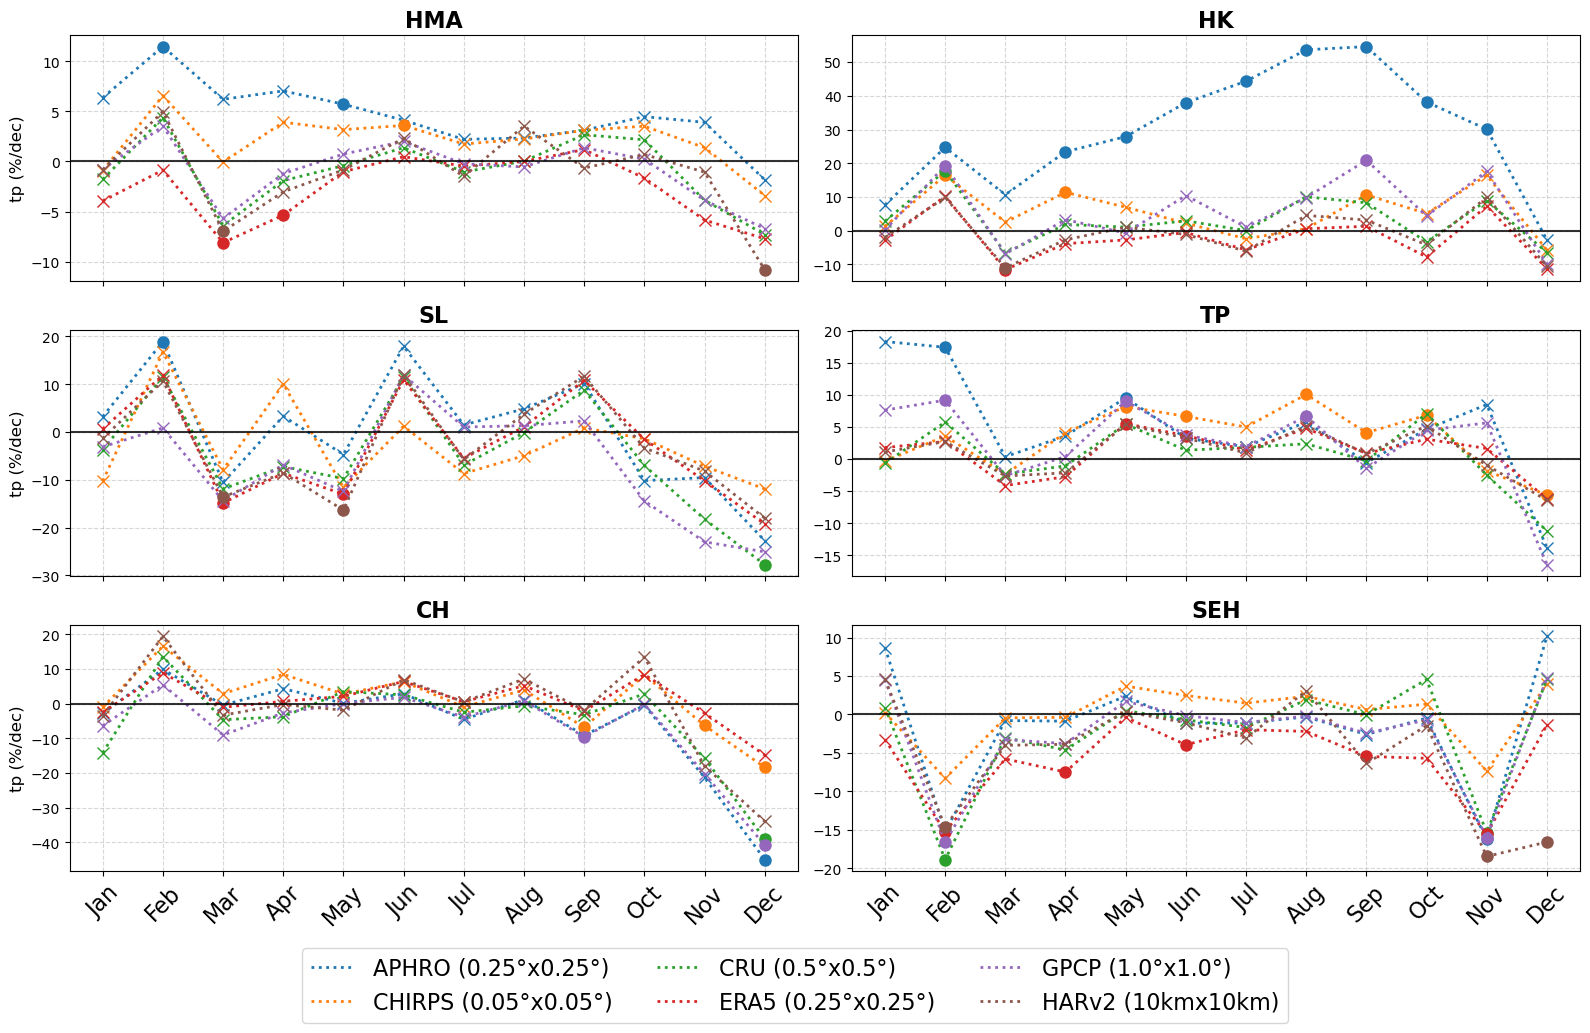

In [19]:
# spatial resolution of the datasets for the legend
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

# Extraire les couleurs Tableau (ordre classique) pour avoir les même couleurs que la figure 3
tableau_colors = list(mcolors.TABLEAU_COLORS.values())

# Assigner une couleur par modèle dans l'ordre
model_colors = {model: tableau_colors[i % len(tableau_colors)] for i, model in enumerate(models)}

# figure
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

for i, dom in enumerate(domains):
    ax = axes[i]
    for model in models:
        slopes = tp_percent_dict[model][dom].values # tendances
        pvalues = tp_pvalue_dict[model][dom].values # p-values
        
        # Créer liste de markers pour chaque mois selon pvalue
        markers = ['x' if p>0.05 else 'o' for p in pvalues]

        # Tracer la ligne en utilisant la couleur automatique et linestyle
        ax.plot(range(1,13), slopes, linestyle=':', linewidth=2, label=f'{model} ({resolutions[model]})',color=model_colors[model])
        
        # Ajouter les markers au-dessus de la ligne
        for m_idx, month_num in enumerate(range(1,13)):
            ax.plot(month_num, slopes[m_idx], marker=markers[m_idx], linestyle='None', markersize=8,color=model_colors[model])

    ax.set_title(dom, fontsize=16, weight="bold") # label of subregions for the subplots
    ax.set_xticks(range(1,13))
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (%/dec)', fontsize=12) # label of y-ax
    if i in [4, 5]:  # ligne du bas
        ax.set_xticklabels(months, rotation=45, fontsize=16) # label of the months
    if i in [0,1,2,3]: # deux premières lignes
        ax.tick_params(labelbottom=False) # pas de label pour les mois
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(y=0,color='black',linestyle='-',linewidth=1.5,alpha=0.8) # ligne horizontale pour la valeur référence de tendance = 0

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(0.5, -0.04),ncol=3,fontsize=16,frameon=True)

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

Figure 7. Annual cycle of precipitation trends over 1981-2015 for the different datasets : characteristics of the datasets present in the legend are provided in Table 1. Total precipitation (tp, %.dec-1). The horizontal black line indicates the zero reference of tp. High Mountain Asia (HMA). Subfigures (b-f) represent subregions (see Fig. 2). Statistically significant trends (p < 0.05) are indicated by dots, whereas non-significant trends (p > 0.05) are represented by crosses.